In [1]:
from fetch_statistics import load_statistics_tables

PE_DB_URL = "http://localhost:8000"

tables = load_statistics_tables(PE_DB_URL)

In [2]:
tables["edit_length"]

,study,count,edit_length
0,deeppe,46825,1
1,deepprime,342537,1
2,minsepie,53,1
3,pridict1,99783,1
4,pridict2,25119,1
...,...,...,...
92,minsepie,308,60
93,minsepie,67,61
94,minsepie,24,63
95,minsepie,18,66


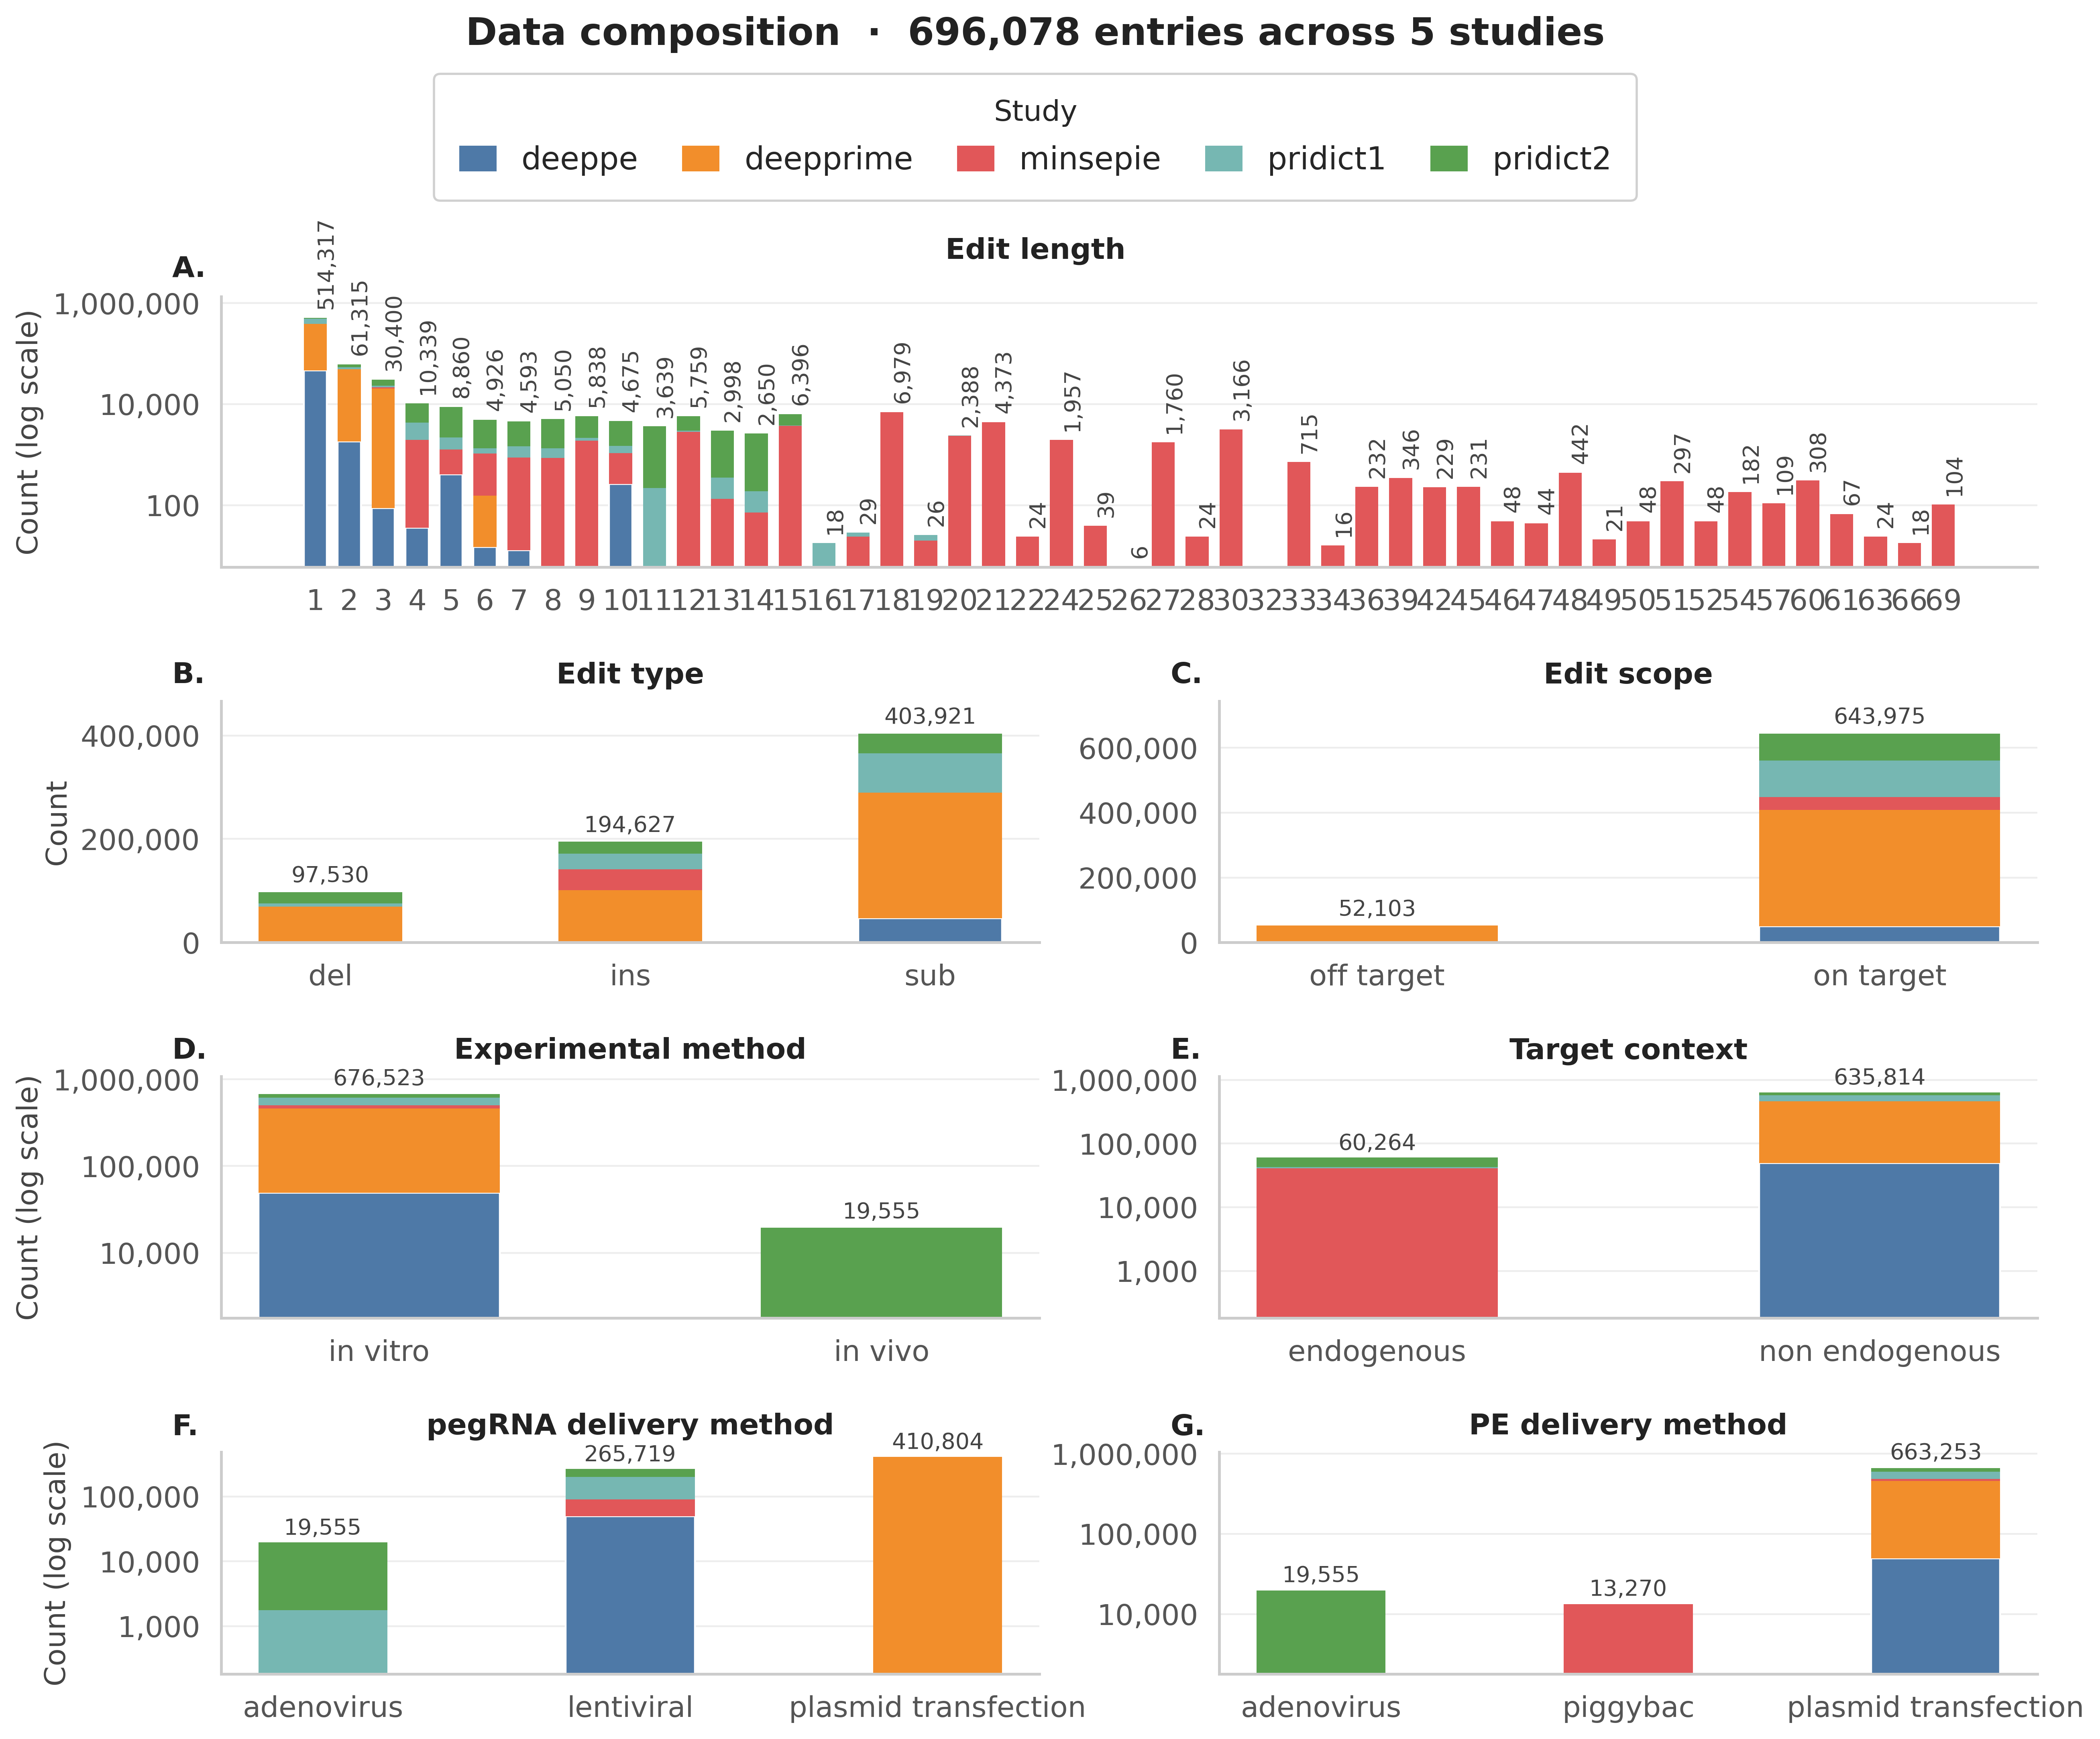

Saved figure to /home/peiheng/development/pe-db/txt/diagrams/data_composition.png


In [3]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns


@dataclass(frozen=True)
class FigureTypography:
    """Adjust these sizes in one place before re-running the cell."""

    subplot_title: float = 13
    panel_label: float = 13
    legend: float = 14
    legend_title: float = 13
    axis_tick: float = 13
    axis_label: float = 13
    bar_value: float = 10
    bar_value_dense_threshold: int = 10
    bar_value_dense_rotation: float = 90
    suptitle: float = 17


FIG_TYPO = FigureTypography()


def apply_figure_typography(typo: FigureTypography = FIG_TYPO) -> None:
    plt.rcParams.update(
        {
            "axes.titlesize": typo.subplot_title,
            "axes.labelsize": typo.axis_label,
            "xtick.labelsize": typo.axis_tick,
            "ytick.labelsize": typo.axis_tick,
        }
    )


# Clean, modern styling
sns.set_theme(style="white", context="notebook", font_scale=1.05)
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.labelcolor": "#444444",
        "axes.titlecolor": "#222222",
        "axes.titleweight": "600",
        "xtick.color": "#555555",
        "ytick.color": "#555555",
        "grid.color": "#E6E6E6",
        "grid.linewidth": 0.8,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)
apply_figure_typography(FIG_TYPO)

LABEL_COLUMNS = {
    "edit_type": "edit_type",
    "edit_length": "edit_length",
    "pegRNA_delivery_method": "delivery_method",
    "pe_delivery_method": "delivery_method",
    "edit_scope": "edit_scope",
    "experimental_method": "experimental_method",
    "target_context": "target_context",
}

PLOT_TITLES = {
    "edit_type": "Edit type",
    "edit_length": "Edit length",
    "pegRNA_delivery_method": "pegRNA delivery method",
    "pe_delivery_method": "PE delivery method",
    "edit_scope": "Edit scope",
    "experimental_method": "Experimental method",
    "target_context": "Target context",
}

UPPER_PANELS = [
    "edit_type",
    "edit_scope",
    "experimental_method",
    "target_context",
]

DELIVERY_PANELS = [
    "pegRNA_delivery_method",
    "pe_delivery_method",
]

STUDY_COLORS = [
    "#4E79A7",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
    "#59A14F",
    "#B07AA1",
    "#FF9DA7",
    "#9C755F",
]


def _format_label(value) -> str:
    return str(value).replace("_", " ")


def _label_order(df: pd.DataFrame, label_col: str) -> list[str]:
    labels = df[label_col].unique().tolist()
    if label_col == "edit_length":
        return [str(v) for v in sorted(labels, key=lambda x: int(x))]
    return [_format_label(v) for v in sorted(labels, key=str)]


def _study_palette(tables: dict[str, pd.DataFrame]) -> tuple[list[str], dict[str, str]]:
    studies = sorted(
        {
            study
            for key, df in tables.items()
            if key != "summary" and not df.empty and "study" in df.columns
            for study in df["study"].dropna().unique()
        }
    )
    colors = STUDY_COLORS[: len(studies)]
    if len(studies) > len(colors):
        colors = sns.color_palette("husl", len(studies)).as_hex()
    return studies, dict(zip(studies, colors))


def _style_axes(ax: plt.Axes, *, show_ylabel: bool, typo: FigureTypography = FIG_TYPO) -> None:
    ax.tick_params(axis="both", labelsize=typo.axis_tick)
    ax.grid(axis="y", linestyle="-", alpha=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.spines["left"].set_color("#CCCCCC")
    ax.spines["bottom"].set_color("#CCCCCC")
    if not show_ylabel:
        ax.set_ylabel("")


def _bar_value_rotation(bar_count: int, *, typo: FigureTypography, override: float | None) -> float:
    if override is not None:
        return override
    if bar_count >= typo.bar_value_dense_threshold:
        return typo.bar_value_dense_rotation
    return 0.0


def _annotate_bar_total(
    ax: plt.Axes,
    bar_x: float,
    total: float,
    *,
    use_log_scale: bool,
    totals_max: float,
    rotation: float,
    typo: FigureTypography,
) -> None:
    label = f"{int(total):,}"
    if rotation:
        ax.annotate(
            label,
            xy=(bar_x, total),
            xytext=(0, 4),
            textcoords="offset points",
            ha="left",
            va="bottom",
            rotation=rotation,
            fontsize=typo.bar_value,
            color="#444444",
            zorder=3,
        )
        return

    label_y = total * 1.12 if use_log_scale else total + max(totals_max * 0.025, 1)
    ax.text(
        bar_x,
        label_y,
        label,
        ha="center",
        va="bottom",
        fontsize=typo.bar_value,
        color="#444444",
        zorder=3,
    )


def _panel_label_fig_x(ref_ax: plt.Axes, *, offset_axes: float = -0.06) -> float:
    pos = ref_ax.get_position()
    return pos.x0 + offset_axes * pos.width


def _add_panel_label(
    ax: plt.Axes,
    label: str,
    *,
    align_fig_x: float | None = None,
    offset_axes: float = -0.06,
    typo: FigureTypography = FIG_TYPO,
) -> None:
    if align_fig_x is not None:
        pos = ax.get_position()
        x = (align_fig_x - pos.x0) / pos.width
    else:
        x = offset_axes
    ax.text(
        x,
        1.05,
        f"{label}.",
        transform=ax.transAxes,
        fontsize=typo.panel_label,
        fontweight="bold",
        color="#222222",
        ha="left",
        va="bottom",
        clip_on=False,
    )


def _add_figure_title(
    fig: plt.Figure,
    ax: plt.Axes,
    title: str,
    *,
    x: float = 0.5,
    typo: FigureTypography = FIG_TYPO,
) -> None:
    pos = ax.get_position()
    fig.text(
        x,
        pos.y1 + 0.018,
        title,
        transform=fig.transFigure,
        ha="center",
        va="bottom",
        fontsize=typo.subplot_title,
        fontweight=plt.rcParams["axes.titleweight"],
        color=plt.rcParams["axes.titlecolor"],
    )


def plot_stacked_study_counts(
    ax: plt.Axes,
    df: pd.DataFrame,
    *,
    label_col: str,
    title: str,
    study_order: list[str],
    study_colors: dict[str, str],
    bar_width: float = 0.72,
    rotate_x: int = 0,
    show_ylabel: bool = True,
    use_log_scale: bool = False,
    fig: plt.Figure | None = None,
    panel_label: str | None = None,
    align_panel_label: bool = False,
    panel_label_fig_x: float | None = None,
    center_title_on_figure: bool = False,
    bar_value_rotation: float | None = None,
    typo: FigureTypography = FIG_TYPO,
) -> None:
    if df.empty:
        if center_title_on_figure and fig is not None:
            _add_figure_title(fig, ax, title, typo=typo)
        else:
            ax.set_title(title, pad=8, fontsize=typo.subplot_title)
        if panel_label:
            _add_panel_label(
                ax,
                panel_label,
                align_fig_x=panel_label_fig_x if align_panel_label else None,
                typo=typo,
            )
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes, color="#888888")
        ax.set_axis_off()
        return

    plot_df = df.copy()
    plot_df["label"] = plot_df[label_col].map(_format_label)
    order = [_format_label(v) for v in _label_order(df, label_col)]

    pivot = (
        plot_df.pivot_table(index="label", columns="study", values="count", aggfunc="sum", fill_value=0)
        .reindex(order)
        .fillna(0)
    )
    for study in study_order:
        if study not in pivot.columns:
            pivot[study] = 0
    pivot = pivot[study_order]

    x = np.arange(len(pivot.index))
    bottom = np.zeros(len(pivot.index))
    for index, study in enumerate(study_order):
        values = pivot[study].to_numpy()
        ax.bar(
            x,
            values,
            bottom=bottom,
            color=study_colors[study],
            edgecolor="white" if index == 0 else "none",
            linewidth=0.8,
            label=study,
            width=bar_width,
            zorder=2,
        )
        bottom += values

    totals = bottom
    value_rotation = _bar_value_rotation(len(x), typo=typo, override=bar_value_rotation)
    for bar_x, total in zip(x, totals):
        if total <= 0:
            continue
        _annotate_bar_total(
            ax,
            bar_x,
            total,
            use_log_scale=use_log_scale,
            totals_max=totals.max(),
            rotation=value_rotation,
            typo=typo,
        )

    if use_log_scale:
        ax.set_yscale("log")
        ylabel = "Count (log scale)" if show_ylabel else ""
    else:
        ylabel = "Count" if show_ylabel else ""
    ax.set_ylabel(ylabel, fontsize=typo.axis_label)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _pos: f"{val:,.0f}"))

    if center_title_on_figure and fig is not None:
        _add_figure_title(fig, ax, title, typo=typo)
    else:
        ax.set_title(title, pad=8, fontsize=typo.subplot_title)
    ax.set_xlabel("")
    ax.set_xticks(x)
    ax.set_xticklabels(
        pivot.index,
        rotation=rotate_x,
        ha="right" if rotate_x else "center",
        fontsize=typo.axis_tick,
    )
    if len(totals) and totals.max() > 0:
        ymin, ymax = ax.get_ylim()
        if value_rotation:
            top_mult = 1.35 if use_log_scale else 1.15
        elif use_log_scale:
            top_mult = 1.18
        else:
            top_mult = 1.1
        ax.set_ylim(bottom=ymin, top=ymax * top_mult)
    _style_axes(ax, show_ylabel=show_ylabel, typo=typo)
    if panel_label:
        _add_panel_label(
            ax,
            panel_label,
            align_fig_x=panel_label_fig_x if align_panel_label else None,
            typo=typo,
        )


study_order, study_colors = _study_palette(tables)

summary = tables["summary"].iloc[0]
fig = plt.figure(figsize=(13, 11), dpi=400)
fig.suptitle(
    f"Data composition  ·  {summary['total_entries']:,} entries across "
    f"{int(summary['total_studies'])} studies",
    fontsize=FIG_TYPO.suptitle,
    fontweight="600",
    color="#222222",
    y=0.999,
)

gs = fig.add_gridspec(
    4,
    2,
    height_ratios=[1.12, 1, 1, 0.92],
    hspace=0.55,
    wspace=0.22,
    top=0.84,
    bottom=0.06,
    left=0.11,
    right=0.98,
)

ax_edit_length = fig.add_subplot(gs[0, :])
upper_axes = [
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[2, 1]),
]
delivery_axes = [
    fig.add_subplot(gs[3, 0]),
    fig.add_subplot(gs[3, 1]),
]
panel_label_fig_x = _panel_label_fig_x(upper_axes[0])

plot_stacked_study_counts(
    ax_edit_length,
    tables["edit_length"],
    label_col=LABEL_COLUMNS["edit_length"],
    title=PLOT_TITLES["edit_length"],
    study_order=study_order,
    study_colors=study_colors,
    bar_width=0.68,
    rotate_x=0,
    show_ylabel=True,
    use_log_scale=True,
    fig=fig,
    panel_label="A",
    align_panel_label=True,
    panel_label_fig_x=panel_label_fig_x,
    center_title_on_figure=True,
)

for index, (ax, name) in enumerate(zip(upper_axes, UPPER_PANELS)):
    plot_stacked_study_counts(
        ax,
        tables[name],
        label_col=LABEL_COLUMNS[name],
        title=PLOT_TITLES[name],
        study_order=study_order,
        study_colors=study_colors,
        bar_width=0.48,
        rotate_x=0,
        show_ylabel=index % 2 == 0,
        use_log_scale=index >= 2,
        panel_label=chr(ord("B") + index),
        align_panel_label=index % 2 == 0,
        panel_label_fig_x=panel_label_fig_x,
    )

# delivery methods for pegRNA and PE
for index, (ax, name) in enumerate(zip(delivery_axes, DELIVERY_PANELS)):
    plot_stacked_study_counts(
        ax,
        tables[name],
        label_col=LABEL_COLUMNS[name],
        title=PLOT_TITLES[name],
        study_order=study_order,
        study_colors=study_colors,
        bar_width=0.42,
        rotate_x=0,
        show_ylabel=index == 0,
        use_log_scale=True,
        panel_label=chr(ord("F") + index),
        align_panel_label=index == 0,
        panel_label_fig_x=panel_label_fig_x,
    )

left_pos = delivery_axes[0].get_position()
right_pos = delivery_axes[1].get_position()
# fig.text(
#     (left_pos.x0 + right_pos.x1) / 2,
#     left_pos.y1 + 0.012,
#     "Delivery methods",
#     ha="center",
#     va="bottom",
#     fontsize=10,
#     fontweight="600",
#     color="#666666",
# )

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=study_colors[study], ec="none") for study in study_order
]
fig.legend(
    legend_handles,
    study_order,
    title="Study",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=min(len(study_order), 5),
    frameon=True,
    fancybox=True,
    shadow=False,
    facecolor="white",
    edgecolor="#D0D0D0",
    framealpha=1.0,
    borderpad=0.8,
    labelspacing=0.6,
    fontsize=FIG_TYPO.legend,
    title_fontsize=FIG_TYPO.legend_title,
    handlelength=1.2,
    handleheight=0.9,
    columnspacing=1.4,
)

output_path = Path("data_composition.png")
fig.savefig(output_path, dpi=600, facecolor="white")
plt.show()

print(f"Saved figure to {output_path.resolve()}")